In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
import os 
import sys

In [2]:
cpp_time_csv = "/workspaces/Thesis/benchmarks/cpp_time.csv"
jl_time_csv = "/workspaces/Thesis/benchmarks/jl_time.csv"

def make_run_folder(name: str) -> str:
    time = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
    os.system(f"mkdir -p runs/{name}-{time}")
    return f"runs/{name}-{time}"

RUN_FOLDER = make_run_folder("ubt_hmap_pu_ndb_watt10")

In [3]:
def calculate_metrics(unboxing, boxing, actual, overhead):
    def average_ns(arr):
        return np.mean(np.array(arr) / 1000)

    def total_ns(arr):
        return np.sum(np.array(arr) / 1000)

    avg_unboxing = average_ns(unboxing)
    avg_boxing = average_ns(boxing)
    avg_actual = average_ns(actual)
    avg_overhead = average_ns(overhead)

    total_unboxing = total_ns(unboxing)
    total_boxing = total_ns(boxing)
    total_actual = total_ns(actual)
    total_overhead = total_ns(overhead)

    data = {
        'Metric': ['Unboxing', 'Boxing', 'Actual', 'Overhead'],
        'Average (µs)': [avg_unboxing, avg_boxing, avg_actual, avg_overhead],
        'Total (µs)': [total_unboxing, total_boxing, total_actual, total_overhead]
    }

    with open(f"{RUN_FOLDER}/metrics_summary.csv", "w") as f:
        pd.DataFrame(data).to_csv(f, index=False)

In [4]:
def draw_boxing_unboxing(unboxing, boxing):
    plt.figure(figsize=(10, 5))

    # Plot unboxing
    plt.plot(unboxing[1:], label='Unboxing', color='blue')

    # Plot boxing
    plt.plot(boxing[1:], label='Boxing', color='red')

    # Calculate min, max, and average for boxing and unboxing
    min_boxing = min(boxing) / 1000
    max_boxing = max(boxing) / 1000
    avg_boxing = sum(boxing) / len(boxing) / 1000

    min_unboxing = min(unboxing) / 1000
    max_unboxing = max(unboxing) / 1000
    avg_unboxing = sum(unboxing) / len(unboxing) / 1000

    # Add annotations
    plt.annotate(f'Min Boxing: {min_boxing:.3f}µs\nMax Boxing: {max_boxing:.3f}µs\nAvg Boxing: {avg_boxing:.3f}µs',
                xy=(0.1, 0.95), xycoords='axes fraction', fontsize=10, verticalalignment='top', color='red')

    plt.annotate(f'Min Unboxing: {min_unboxing:.3f}µs\nMax Unboxing: {max_unboxing:.3f}µs\nAvg Unboxing: {avg_unboxing:.3f}µs',
                xy=(0.1, 0.80), xycoords='axes fraction', fontsize=10, verticalalignment='top', color='blue')

    plt.title('Boxing and Unboxing Over Time')
    plt.xlabel('Iteration')
    plt.ylabel('Time (ns)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{RUN_FOLDER}/boxing_unboxing_over_time.png")

In [5]:
def draw_overhead(overhead): 
    plt.figure(figsize=(10, 5))

    # Plot overhead in log scale
    plt.plot(overhead[1:], label='Overhead', color='green')
    plt.title('Overhead Over Time')
    plt.xlabel('Iteration')
    plt.ylabel('Time (ns)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{RUN_FOLDER}/overhead_over_time.png")

In [6]:
def draw_overlayed(unboxing, boxing, overhead): 
    plt.figure(figsize=(10, 5))

    # Plot unboxing
    plt.plot(unboxing[1:], label='Unboxing', color='blue', alpha=0.5)

    # Plot boxing
    plt.plot(boxing[1:], label='Boxing', color='red', alpha=0.5)

    # Plot overhead
    plt.plot(overhead[1:], label='Overhead', color='green', alpha=0.5)

    plt.title('Boxing, Unboxing, and Overhead Over Time')
    plt.xlabel('Iteration')
    plt.ylabel('Time (ns)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{RUN_FOLDER}/overlayed_over_time.png")

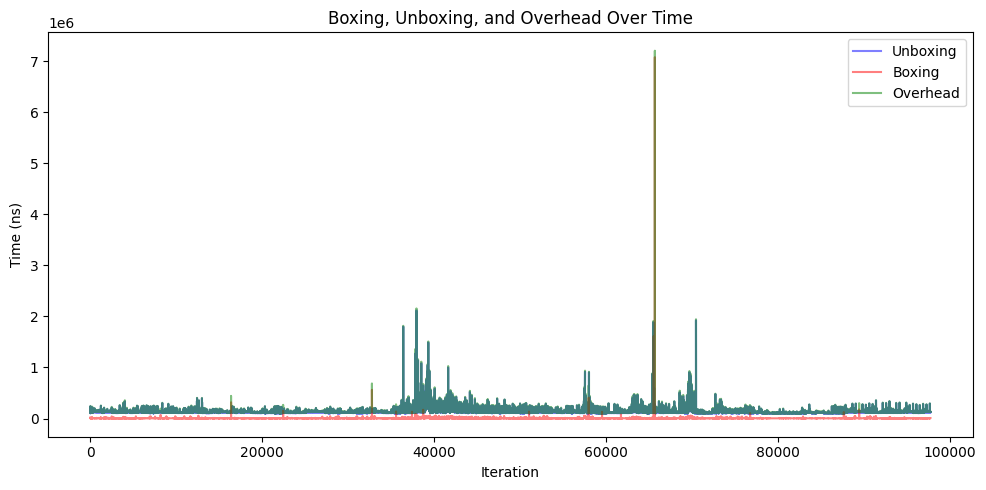

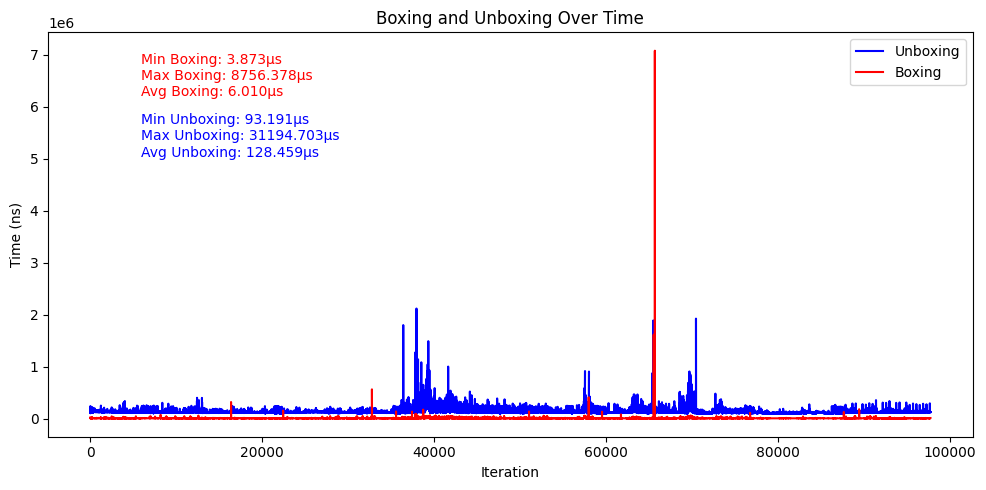

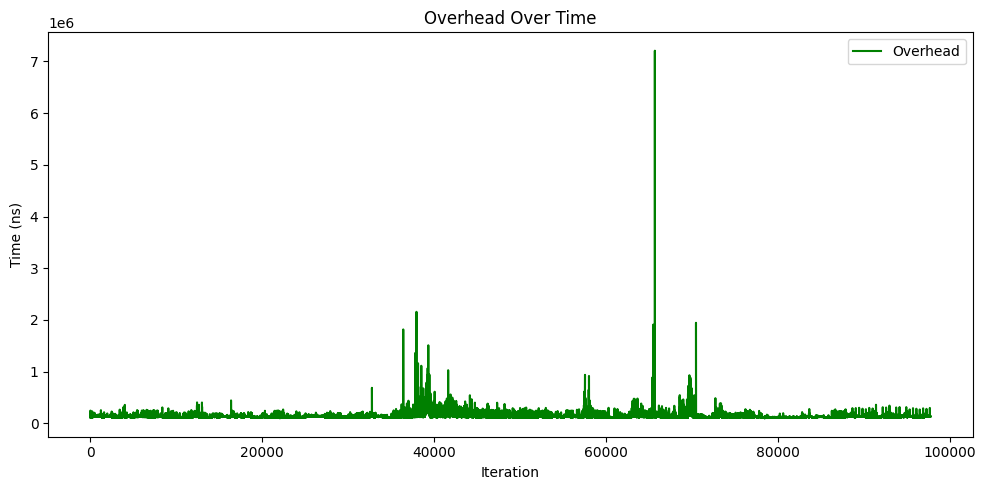

In [7]:
def chunk(arr, size) -> list:
    return [arr[i:i+size] for i in range(0, len(arr), size)]

@dataclass
class TimeInfo:
    t1: int
    t2: int
    tt: int

def read_csv(file: str) -> list[TimeInfo]:
    with open(file, "r") as f:
        return [TimeInfo(*map(int, a.split(","))) for a in f.readlines()]

class TimeSeries:
    def __init__(self, unboxing, boxing, actual):
        self.unboxing = unboxing
        self.boxing = boxing
        self.actual = actual 
        self.overhead = self.unboxing + self.boxing
        
    def __str__(self):
        return f"Unboxing: {self.unboxing}, Boxing: {self.boxing}, Actual: {self.actual}, Overhead: {self.overhead} (Total: {self.unboxing + self.boxing + self.actual})"

benchmarks = list(map(lambda x: TimeSeries(x[1].t1 - x[0].t1, x[0].t2 - x[1].t2, x[1].tt), zip(read_csv(jl_time_csv), read_csv(cpp_time_csv))))

unboxing, boxing, actual, overhead = zip(*[(x.unboxing, x.boxing, x.actual, x.overhead) for x in benchmarks])

calculate_metrics(unboxing, boxing, actual, overhead)
draw_overlayed(unboxing, boxing, overhead)
draw_boxing_unboxing(unboxing, boxing)
draw_overhead(overhead)

def move_timing_files(): 
    os.system(f"mv {cpp_time_csv} {RUN_FOLDER}/cpp_time.csv")
    os.system(f"mv {jl_time_csv} {RUN_FOLDER}/jl_time.csv")
    
move_timing_files()